# Modeling Human Activity States Using Hidden Markov Models

**Hidden states (Z):** standing, walking, jumping, still
**Observations (X):** feature vectors from accelerometer + gyroscope windows
**Model:** Gaussian HMM from scratch (numpy): Baum-Welch training with a
log-likelihood convergence check, Viterbi decoding in log space.

In [13]:
from google.colab import drive
drive.mount('/content/drive')

import glob, os, zipfile
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp

# Sampling-rate harmonization: every recording is resampled onto a uniform
# 50 Hz grid, so windows are comparable regardless of the phone's native rate.
TARGET_FS = 50
# Window logic: walking ~1.5-2.5 Hz, jumping ~2-3 Hz, so a 1 s window at 50 Hz
# captures at least one full movement cycle and gives 1 Hz FFT resolution.
WINDOW_SEC = 1.0
OVERLAP = 0.5
WINDOW = int(TARGET_FS * WINDOW_SEC)
STEP = int(WINDOW * (1 - OVERLAP))

ACTIVITIES = ["standing", "walking", "jumping", "still"]

RAW_ZIPS = "/content/drive/MyDrive/hmm_data"
RAW_DIR = "/content/raw"
TRAIN_DIR = "/content/data/train"
TEST_DIR = "/content/data/test"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
SLICE_SEC = 5.0      # length of each single-activity file
TRIM_SEC = 3.0       # cut from start AND end (start/stop button artifacts)

# Mixed recordings listed here become labelled TEST files; any other mixed
# recording goes entirely to TRAINING (Baum-Welch needs no labels there,
# only real activity transitions). Segment times are AFTER the 3 s trim:
# each entry means "this activity lasts until this second".
MIXED_TESTS = {
    "all_activities_2": [(17.0, "standing"), (37.0, "walking"),
                         (55.0, "jumping"), (np.inf, "walking")],
    # when you record the energetic-jumps session, adjust these timings:
   "all_activities_3": [(17.0, "standing"), (39.0, "walking"),
                         (68.0, "jumping"), (np.inf, "walking")],
}

ACTIVITY_PATTERNS = {
    "still": ["still", "no_movement"],
    "walking": ["walking", "walk"],
    "jumping": ["jumping", "jump"],
    "standing": ["standing", "stand"],
}

def detect_activity(folder_name):
    name = folder_name.lower()
    for act, pats in ACTIVITY_PATTERNS.items():
        if any(p in name for p in pats):
            return act
    return "mixed"

def merge_recording(folder):
    """Merge Accelerometer.csv + Gyroscope.csv onto shared timestamps."""
    acc = pd.read_csv(os.path.join(folder, "Accelerometer.csv"))
    gyr = pd.read_csv(os.path.join(folder, "Gyroscope.csv"))
    t = acc["seconds_elapsed"].values
    df = pd.DataFrame({
        "time": t - t[0],
        "ax": acc["x"], "ay": acc["y"], "az": acc["z"],
        "gx": np.interp(t, gyr["seconds_elapsed"], gyr["x"]),
        "gy": np.interp(t, gyr["seconds_elapsed"], gyr["y"]),
        "gz": np.interp(t, gyr["seconds_elapsed"], gyr["z"]),
    })
    fs = len(df) / (df["time"].iloc[-1] - df["time"].iloc[0])
    return df, fs

# 1. unzip every export from Drive onto Colab's local disk
os.makedirs(RAW_DIR, exist_ok=True)
for z in glob.glob(os.path.join(RAW_ZIPS, "*.zip")):
    out = os.path.join(RAW_DIR, os.path.basename(z)[:-4])
    os.makedirs(out, exist_ok=True)
    zipfile.ZipFile(z).extractall(out)

# 2. merge, trim, slice, label
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)
counters = {}
mixed_train_n = 0
for folder in sorted(glob.glob(os.path.join(RAW_DIR, "*"))):
    act = detect_activity(os.path.basename(folder))
    df, fs = merge_recording(folder)

    t_end = df["time"].iloc[-1]
    df = df[(df.time >= TRIM_SEC) & (df.time <= t_end - TRIM_SEC)].copy()
    df["time"] -= df["time"].iloc[0]
    dur = df["time"].iloc[-1]
    print(f"{os.path.basename(folder):50s} {act:9s} {dur:6.1f}s {fs:5.0f} Hz")

    if act == "mixed":
        matched = next((k for k in MIXED_TESTS if k in os.path.basename(folder)), None)
        if matched:
            n = list(MIXED_TESTS).index(matched) + 1
            out = f"{TEST_DIR}/mixed_test_{n:02d}.csv"
            df.to_csv(out, index=False)
            # per-window ground-truth labels, matching the pipeline's exact
            # resampling and windowing (label decided by window CENTER time)
            t2 = df["time"].values
            grid = np.arange(t2[0], t2[-1], 1.0 / TARGET_FS)
            labels = []
            for start in range(0, len(grid) - WINDOW + 1, STEP):
                center = grid[start] + (WINDOW / 2) / TARGET_FS
                labels.append(next(lab for end, lab in MIXED_TESTS[matched] if center < end))
            pd.DataFrame({"label": labels}).to_csv(out.replace(".csv", "_labels.csv"), index=False)
            print(f"   -> labelled test file: {pd.Series(labels).value_counts().to_dict()}")
        else:
            mixed_train_n += 1
            df.to_csv(f"{TRAIN_DIR}/mixed_train_{mixed_train_n:02d}.csv", index=False)
    else:
        for i in range(int(dur // SLICE_SEC)):
            sl = df[(df.time >= i*SLICE_SEC) & (df.time < (i+1)*SLICE_SEC)].copy()
            sl["time"] -= sl["time"].iloc[0]
            counters[act] = counters.get(act, 0) + 1
            # every 6th slice of each activity is held out as unseen test data
            out_dir = TEST_DIR if counters[act] % 6 == 0 else TRAIN_DIR
            sl.to_csv(f"{out_dir}/{act}_{counters[act]:02d}.csv", index=False)

print(f"\n{len(glob.glob(TRAIN_DIR+'/*.csv'))} training files, "
      f"{len([f for f in glob.glob(TEST_DIR+'/*.csv') if not f.endswith('_labels.csv')])} test files")

Jumping2-2026-07-02_08-21-53                       jumping     26.2s   100 Hz
Jumping_3-2026-07-02_08-25-14                      jumping     25.7s   100 Hz
Jumping_4-2026-07-02_08-26-06 (1)                  jumping     34.9s   100 Hz
all_activities-2026-07-02_08-27-06                 mixed       95.9s   100 Hz
all_activities_2-2026-07-02_08-54-55               mixed       65.5s   100 Hz
   -> labelled test file: {'walking': 61, 'jumping': 36, 'standing': 33}
all_activities_3-2026-07-03_13-19-55               mixed      113.9s   100 Hz
   -> labelled test file: {'walking': 135, 'jumping': 58, 'standing': 33}
jumping1_30sec-2026-07-02_08-21-03                 jumping     25.8s   100 Hz
standing_with_phone-2026-07-02_08-45-09            standing   116.2s   100 Hz
still_no_movement_-2026-07-02_08-29-32             still      120.6s   100 Hz
walking-2026-07-02_08-18-17                        walking    116.9s   100 Hz

79 training files, 15 test files


In [15]:
def resample_to_grid(df, fs=TARGET_FS):
    """Harmonization: resample all 6 axes onto a uniform grid at fs Hz."""
    t = df["time"].values
    grid = np.arange(t[0], t[-1], 1.0 / fs)
    out = {"time": grid}
    for c in ["ax", "ay", "az", "gx", "gy", "gz"]:
        out[c] = np.interp(grid, t, df[c].values)
    return pd.DataFrame(out)

def activity_from_filename(path):
    name = os.path.basename(path).lower()
    for a in ACTIVITIES:
        if name.startswith(a):
            return a
    return "mixed"

def load_folder(folder):
    records = []
    for path in sorted(glob.glob(os.path.join(folder, "*.csv"))):
        if path.endswith("_labels.csv"):
            continue
        df = pd.read_csv(path)
        records.append((resample_to_grid(df), activity_from_filename(path), path))
    return records

train_records = load_folder(TRAIN_DIR)
test_records = load_folder(TEST_DIR)
print(f"Loaded {len(train_records)} training files, {len(test_records)} test files.")

Loaded 79 training files, 15 test files.


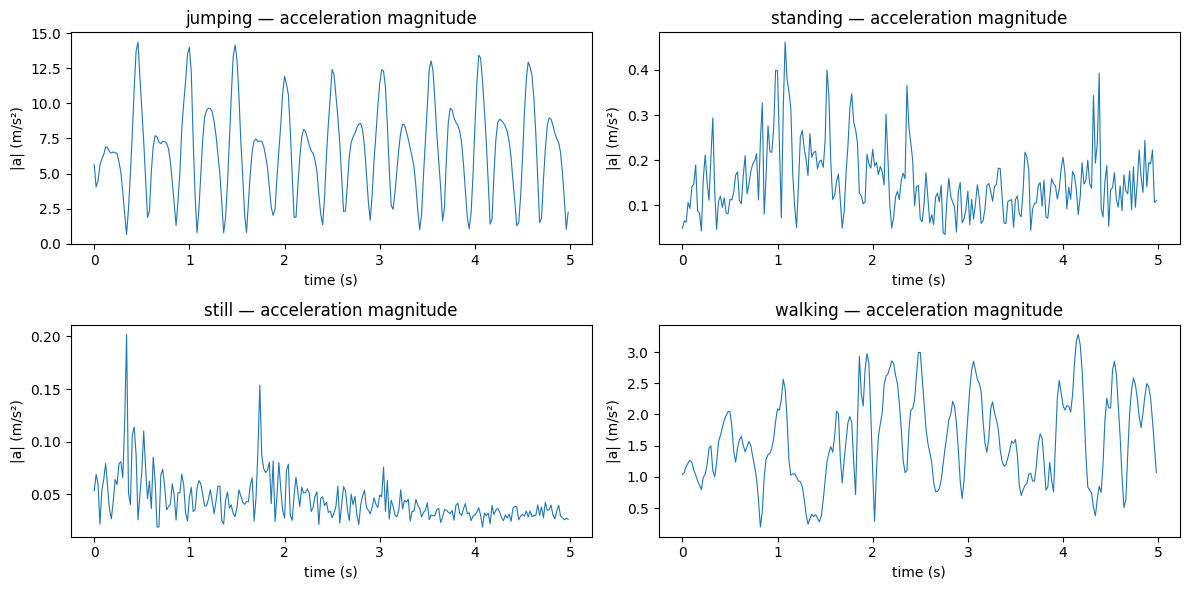

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
shown = set()
for df, act, path in train_records:
    if act in shown or act == "mixed":
        continue
    ax = axes.flat[len(shown)]
    mag = np.sqrt(df.ax**2 + df.ay**2 + df.az**2)
    ax.plot(df.time, mag, lw=0.8)
    ax.set_title(f"{act} — acceleration magnitude")
    ax.set_xlabel("time (s)"); ax.set_ylabel("|a| (m/s²)")
    shown.add(act)
plt.tight_layout(); plt.show()

## Feature extraction

Per 1 s window: **5 time-domain** and **2 FFT-derived frequency-domain** features.
Intensity features are log-transformed: jumping values are enormous, and the log
spreads out the quiet end of the scale where still and standing differ.

| Feature | Domain | Why it separates activities |
|---|---|---|
| mean accel magnitude | time | overall motion level per window |
| log std accel magnitude | time | still ≈ 0 < standing tremor < walking < jumping |
| log RMS accel magnitude | time | movement intensity |
| log SMA | time | classic activity-recognition intensity measure |
| log std gyro magnitude | time | rotation separates held phone from resting phone |
| dominant frequency (FFT) | freq | walking ~1.5-2.5 Hz vs jumping ~2-4 Hz |
| log spectral energy (FFT) | freq | periodic power, near zero when quiet |

In [17]:
FEATURE_NAMES = ["acc_mean", "log_std", "log_rms", "log_sma",
                 "log_gyr_std", "dom_freq", "log_energy"]

def window_features(w, fs=TARGET_FS):
    acc = w[["ax", "ay", "az"]].values
    gyr = w[["gx", "gy", "gz"]].values
    acc_mag = np.linalg.norm(acc, axis=1)
    gyr_mag = np.linalg.norm(gyr, axis=1)

    x = acc_mag - acc_mag.mean()                    # detrend before FFT
    spec = np.abs(np.fft.rfft(x))
    freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
    dom_freq = freqs[np.argmax(spec[1:]) + 1] if len(spec) > 1 else 0.0

    return np.array([
        acc_mag.mean(),
        np.log1p(acc_mag.std()),
        np.log1p(np.sqrt(np.mean(acc_mag ** 2))),
        np.log1p(np.mean(np.abs(acc).sum(axis=1))),
        np.log1p(gyr_mag.std()),
        dom_freq,
        np.log1p(np.sum(spec ** 2) / len(x)),
    ])

def to_sequence(df):
    """Sliding window over one recording -> (num_windows, num_features)."""
    return np.array([window_features(df.iloc[s:s + WINDOW])
                     for s in range(0, len(df) - WINDOW + 1, STEP)])

train_seqs_raw = [(to_sequence(df), act) for df, act, _ in train_records]
test_seqs_raw = [(to_sequence(df), act, path) for df, act, path in test_records]

In [18]:
X_train_all = np.vstack([s for s, _ in train_seqs_raw])
MU, SIGMA = X_train_all.mean(axis=0), X_train_all.std(axis=0) + 1e-8

def normalize(X):
    return (X - MU) / SIGMA

train_seqs = [(normalize(s), act) for s, act in train_seqs_raw]
test_seqs = [(normalize(s), act, path) for s, act, path in test_seqs_raw]

In [19]:
class GaussianHMM:
    """HMM with diagonal-Gaussian emissions over continuous feature vectors.
    All recursions run in log space to avoid numerical underflow on long
    sequences (products of hundreds of probabilities underflow float64)."""

    def __init__(self, n_states, seed=42):
        self.K = n_states
        self.rng = np.random.default_rng(seed)
        self.loglik_history = []

    def _init_params(self, seqs, init_means=None, init_vars=None):
        X_all = np.vstack(seqs)
        if init_means is not None:
            # informed initialization from labelled data keeps hidden state k
            # aligned with ACTIVITIES[k] and avoids poor EM local optima
            self.means = init_means.copy()
            self.vars = init_vars.copy()
        else:
            idx = self.rng.choice(len(X_all), self.K, replace=False)
            self.means = X_all[idx].copy()
            self.vars = np.tile(X_all.var(axis=0) + 1e-2, (self.K, 1))
        A = self.rng.random((self.K, self.K)) + 5.0 * np.eye(self.K)
        self.A = A / A.sum(axis=1, keepdims=True)   # sticky start: activities persist
        self.pi = np.full(self.K, 1.0 / self.K)

    def _log_emission(self, X):
        """log N(x_t | mean_k, diag(var_k)) for every window t, state k -> (T,K)"""
        diff = X[:, None, :] - self.means[None, :, :]
        return -0.5 * (np.sum(diff ** 2 / self.vars[None], axis=2)
                       + np.sum(np.log(2 * np.pi * self.vars), axis=1)[None, :])

    def _forward(self, logB):
        T = logB.shape[0]
        log_alpha = np.zeros((T, self.K))
        log_alpha[0] = np.log(self.pi + 1e-300) + logB[0]
        logA = np.log(self.A + 1e-300)
        for t in range(1, T):
            log_alpha[t] = logsumexp(log_alpha[t-1][:, None] + logA, axis=0) + logB[t]
        return log_alpha, logsumexp(log_alpha[-1])

    def _backward(self, logB):
        T = logB.shape[0]
        log_beta = np.zeros((T, self.K))
        logA = np.log(self.A + 1e-300)
        for t in range(T - 2, -1, -1):
            log_beta[t] = logsumexp(logA + (logB[t+1] + log_beta[t+1])[None, :], axis=1)
        return log_beta

    def fit(self, seqs, max_iter=200, tol=1e-4, verbose=True,
            init_means=None, init_vars=None):
        """Baum-Welch (EM) over multiple sequences.
        Convergence criterion: |Δ total log-likelihood| < tol."""
        self._init_params(seqs, init_means, init_vars)
        prev_ll = -np.inf
        self.loglik_history = []
        for it in range(max_iter):
            total_ll = 0.0
            pi_acc = np.zeros(self.K)
            xi_acc = np.zeros((self.K, self.K))     # expected transition counts
            gamma_acc = np.zeros(self.K)            # expected state occupancy
            mean_acc = np.zeros_like(self.means)
            var_acc = np.zeros_like(self.vars)
            logA = np.log(self.A + 1e-300)

            for X in seqs:                          # ----- E step -----
                logB = self._log_emission(X)
                log_alpha, ll = self._forward(logB)
                log_beta = self._backward(logB)
                total_ll += ll
                gamma = np.exp(log_alpha + log_beta - ll)
                for t in range(X.shape[0] - 1):
                    xi_acc += np.exp(log_alpha[t][:, None] + logA
                                     + (logB[t+1] + log_beta[t+1])[None, :] - ll)
                pi_acc += gamma[0]
                gamma_acc += gamma.sum(axis=0)
                mean_acc += gamma.T @ X
                var_acc += gamma.T @ (X ** 2)

            self.pi = pi_acc / len(seqs)            # ----- M step -----
            self.A = xi_acc / xi_acc.sum(axis=1, keepdims=True)
            self.means = mean_acc / gamma_acc[:, None]
            self.vars = np.maximum(var_acc / gamma_acc[:, None] - self.means**2, 1e-3)

            self.loglik_history.append(total_ll)    # ----- convergence -----
            delta = total_ll - prev_ll
            if verbose and (it % 10 == 0 or abs(delta) < tol):
                print(f"iter {it:3d}  log-likelihood = {total_ll:.2f}  Δ = {delta:.6f}")
            if abs(delta) < tol:
                print(f"Converged at iteration {it}.")
                break
            prev_ll = total_ll
        return self

    def viterbi(self, X):
        """Most likely hidden state path (log space, with backpointers)."""
        logB = self._log_emission(X)
        T = X.shape[0]
        logA = np.log(self.A + 1e-300)
        delta = np.zeros((T, self.K))
        psi = np.zeros((T, self.K), dtype=int)
        delta[0] = np.log(self.pi + 1e-300) + logB[0]
        for t in range(1, T):
            scores = delta[t-1][:, None] + logA
            psi[t] = np.argmax(scores, axis=0)
            delta[t] = scores[psi[t], np.arange(self.K)] + logB[t]
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])
        for t in range(T - 2, -1, -1):
            path[t] = psi[t+1, path[t+1]]
        return path

iter   0  log-likelihood = 1508.42  Δ = inf
iter  10  log-likelihood = 3825.59  Δ = 0.040141
iter  16  log-likelihood = 3825.60  Δ = 0.000048
Converged at iteration 16.


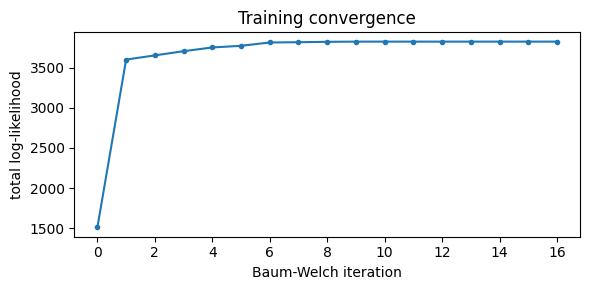

In [20]:
# We know which activity each single-activity file contains, so each hidden
# state's Gaussian starts at that activity's mean feature vector. Baum-Welch
# then refines everything jointly (including on the unlabelled mixed session).
init_means = np.stack([
    np.vstack([s for s, act in train_seqs if act == a]).mean(axis=0)
    for a in ACTIVITIES])
init_vars = np.stack([
    np.vstack([s for s, act in train_seqs if act == a]).var(axis=0) + 1e-2
    for a in ACTIVITIES])

model = GaussianHMM(n_states=len(ACTIVITIES), seed=7)
model.fit([s for s, _ in train_seqs], max_iter=200, tol=1e-4,
          init_means=init_means, init_vars=init_vars)

plt.figure(figsize=(6, 3))
plt.plot(model.loglik_history, marker="o", ms=3)
plt.xlabel("Baum-Welch iteration"); plt.ylabel("total log-likelihood")
plt.title("Training convergence"); plt.tight_layout(); plt.show()

In [21]:
votes = {k: Counter() for k in range(len(ACTIVITIES))}
for X, act in train_seqs:
    if act == "mixed":
        continue
    for s in model.viterbi(X):
        votes[s][act] += 1
state2act = {k: (votes[k].most_common(1)[0][0] if votes[k] else ACTIVITIES[k])
             for k in votes}
print("hidden state -> activity:", state2act)

hidden state -> activity: {0: 'standing', 1: 'walking', 2: 'jumping', 3: 'still'}


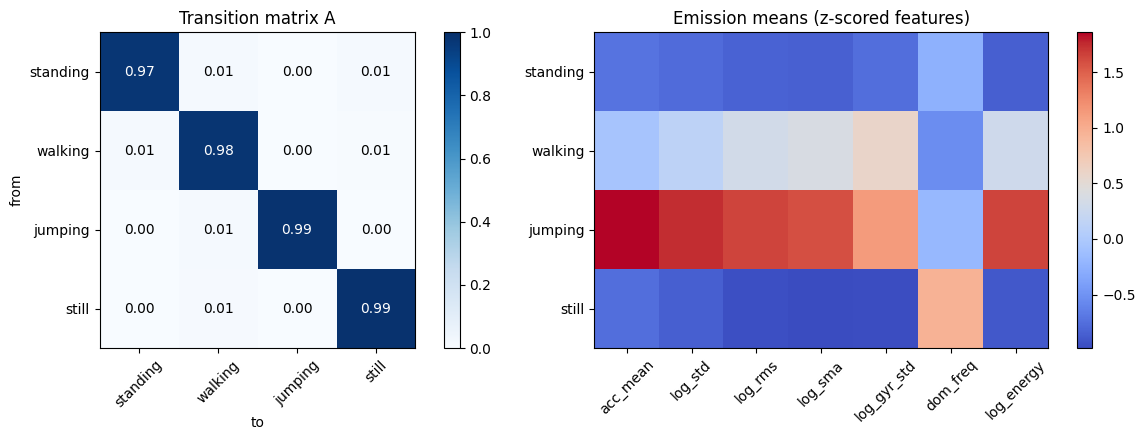

In [22]:
order = list(range(len(ACTIVITIES)))
labels = [state2act[k] for k in order]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
im0 = axes[0].imshow(model.A, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(order, labels, rotation=45); axes[0].set_yticks(order, labels)
axes[0].set_title("Transition matrix A"); axes[0].set_xlabel("to"); axes[0].set_ylabel("from")
for i in order:
    for j in order:
        axes[0].text(j, i, f"{model.A[i, j]:.2f}", ha="center", va="center",
                     color="white" if model.A[i, j] > 0.5 else "black")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(model.means, cmap="coolwarm", aspect="auto")
axes[1].set_yticks(order, labels)
axes[1].set_xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=45)
axes[1].set_title("Emission means (z-scored features)")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout(); plt.show()

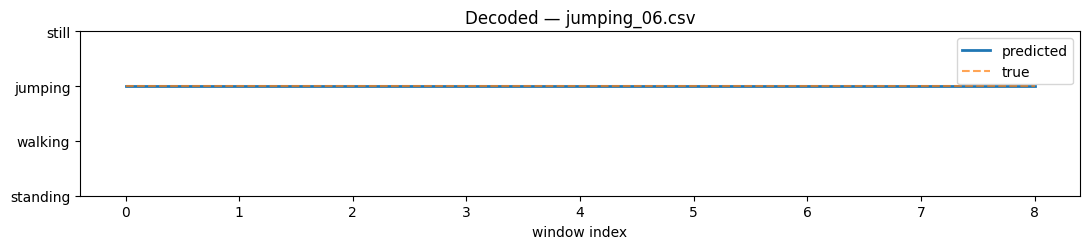

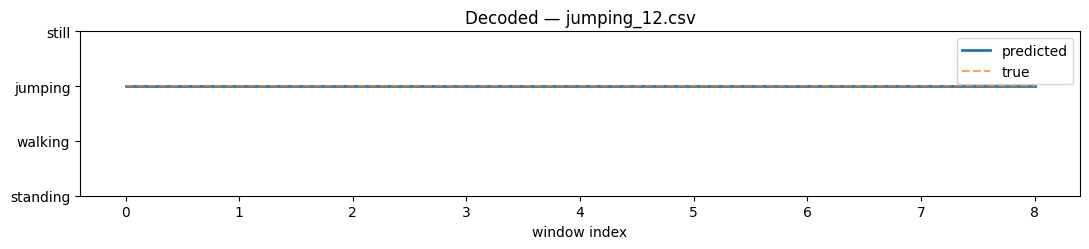

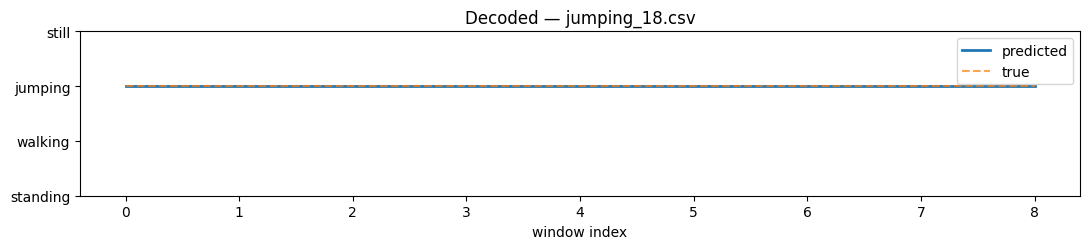

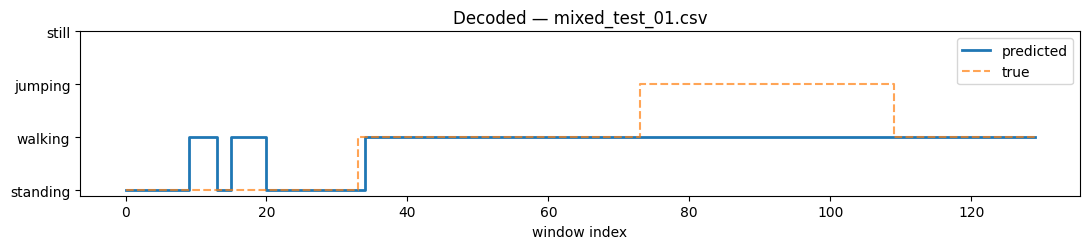

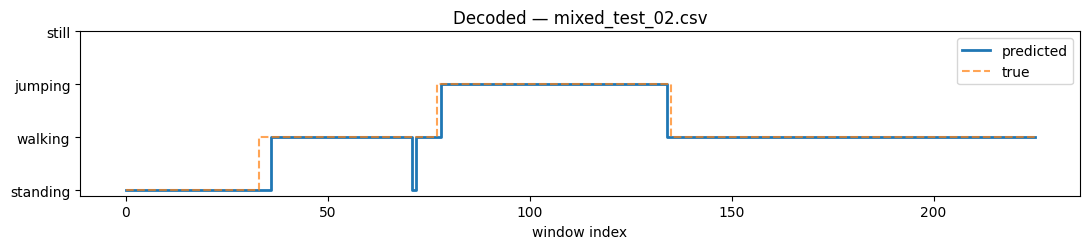

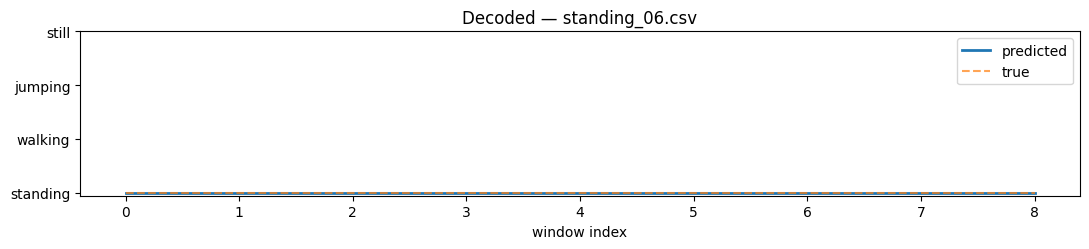

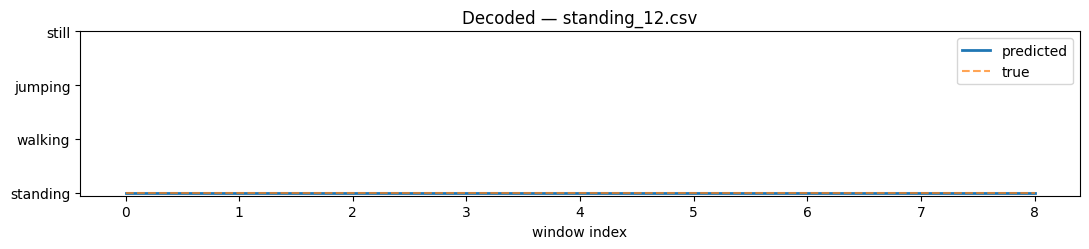

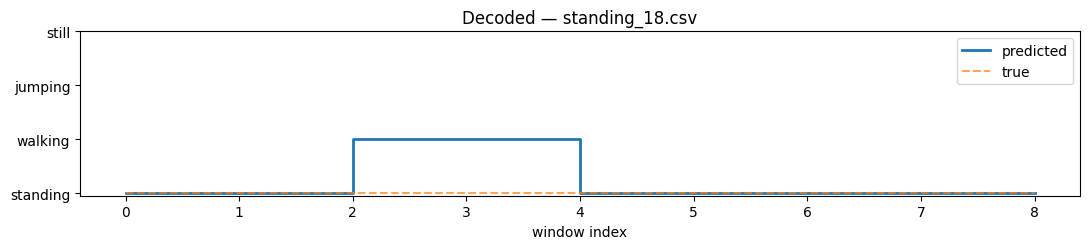

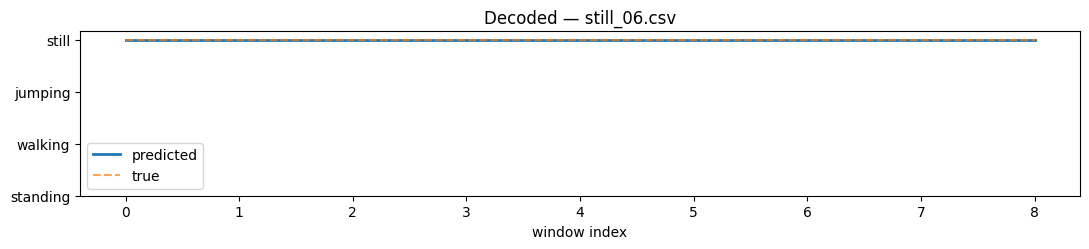

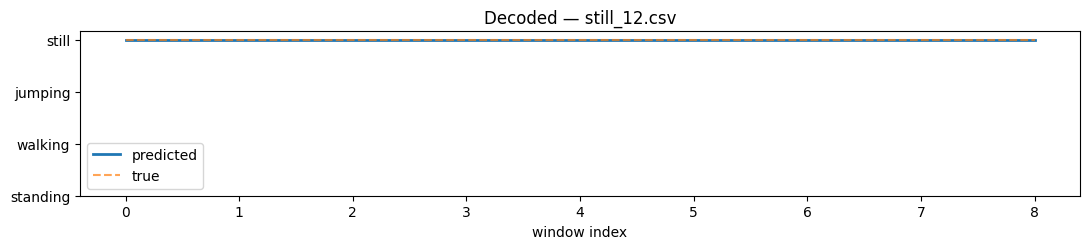

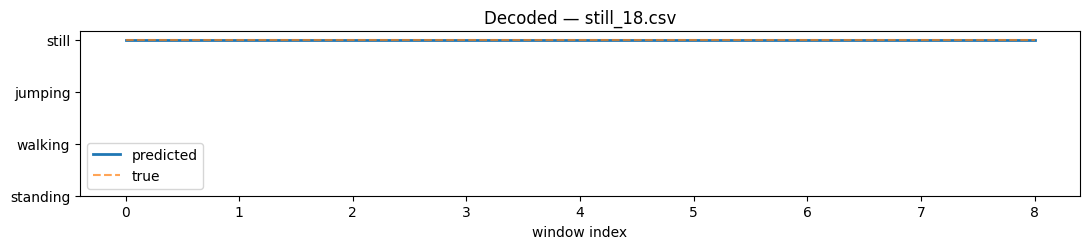

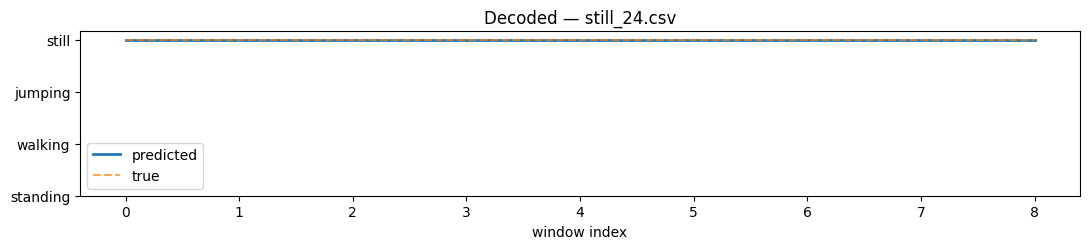

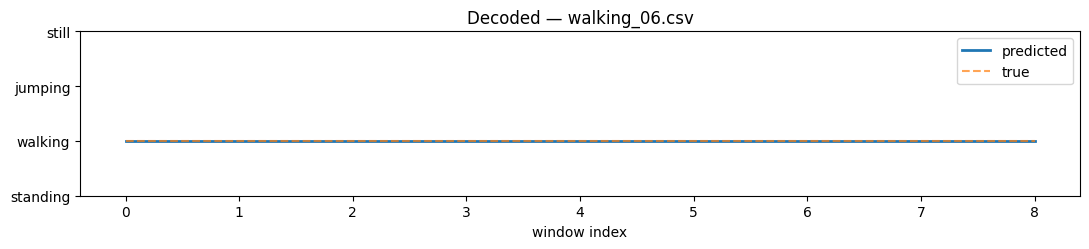

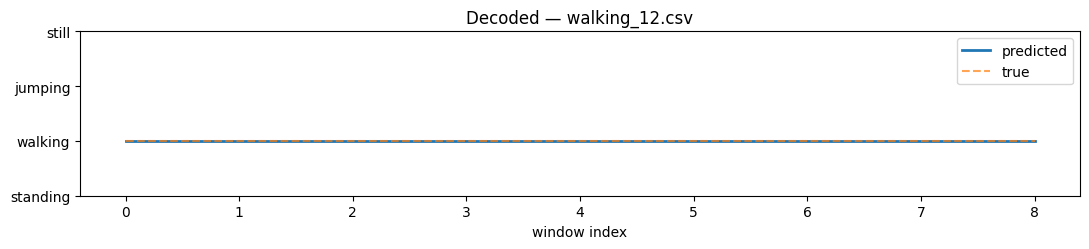

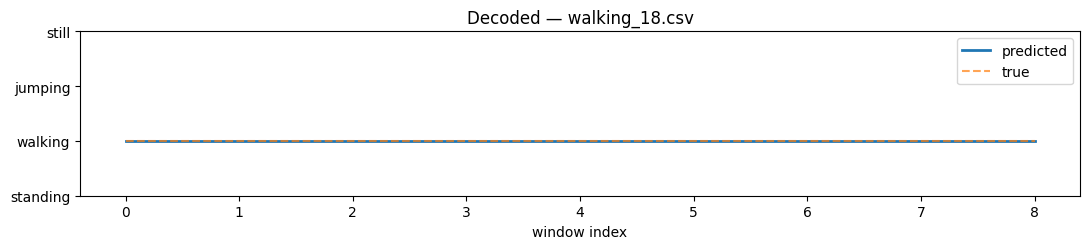

In [23]:
act2idx = {a: i for i, a in enumerate(ACTIVITIES)}
y_true_all, y_pred_all = [], []

for X, act, path in test_seqs:
    pred = np.array([state2act[s] for s in model.viterbi(X)])

    label_file = path.replace(".csv", "_labels.csv")
    if os.path.exists(label_file):        # per-window labels for mixed test files
        truth = pd.read_csv(label_file)["label"].astype(str).str.lower().values[:len(pred)]
    elif act != "mixed":                  # single-activity file: filename is truth
        truth = np.array([act] * len(pred))
    else:
        truth = None

    plt.figure(figsize=(11, 2.6))
    plt.step(range(len(pred)), [act2idx[p] for p in pred], where="post",
             label="predicted", lw=2)
    if truth is not None:
        plt.step(range(len(truth)), [act2idx[t] for t in truth], where="post",
                 label="true", ls="--", alpha=0.7)
        y_true_all += list(truth); y_pred_all += list(pred[:len(truth)])
    plt.yticks(range(len(ACTIVITIES)), ACTIVITIES)
    plt.xlabel("window index"); plt.title(f"Decoded — {os.path.basename(path)}")
    plt.legend(); plt.tight_layout(); plt.show()

State (Activity)  Number of Samples  Sensitivity  Specificity  Overall Accuracy
        standing                 93        0.882        0.987             0.886
         walking                223        0.978        0.804             0.886
         jumping                121        0.686        1.000             0.886
           still                 36        1.000        1.000             0.886


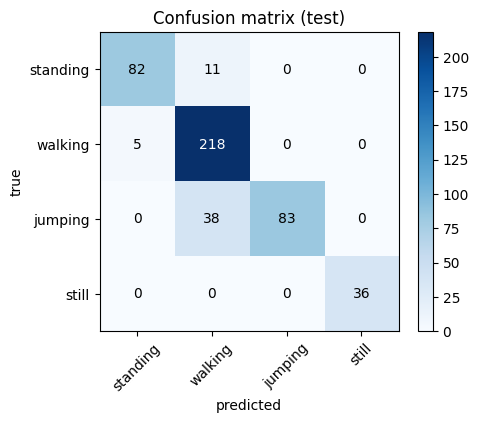

In [24]:
def per_class_metrics(y_true, y_pred, classes):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rows = []
    for c in classes:
        tp = np.sum((y_true == c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        fp = np.sum((y_true != c) & (y_pred == c))
        tn = np.sum((y_true != c) & (y_pred != c))
        rows.append({"State (Activity)": c, "Number of Samples": int(tp + fn),
                     "Sensitivity": tp / (tp + fn) if tp + fn else np.nan,
                     "Specificity": tn / (tn + fp) if tn + fp else np.nan})
    df = pd.DataFrame(rows)
    df["Overall Accuracy"] = (y_true == y_pred).mean()
    return df

metrics = per_class_metrics(y_true_all, y_pred_all, ACTIVITIES)
print(metrics.round(3).to_string(index=False))

cm = np.zeros((len(ACTIVITIES), len(ACTIVITIES)), dtype=int)
for t, p in zip(y_true_all, y_pred_all):
    cm[act2idx[t], act2idx[p]] += 1
plt.figure(figsize=(5, 4.2))
plt.imshow(cm, cmap="Blues")
plt.xticks(range(len(ACTIVITIES)), ACTIVITIES, rotation=45)
plt.yticks(range(len(ACTIVITIES)), ACTIVITIES)
plt.xlabel("predicted"); plt.ylabel("true"); plt.title("Confusion matrix (test)")
for i in range(len(ACTIVITIES)):
    for j in range(len(ACTIVITIES)):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(); plt.tight_layout(); plt.show()

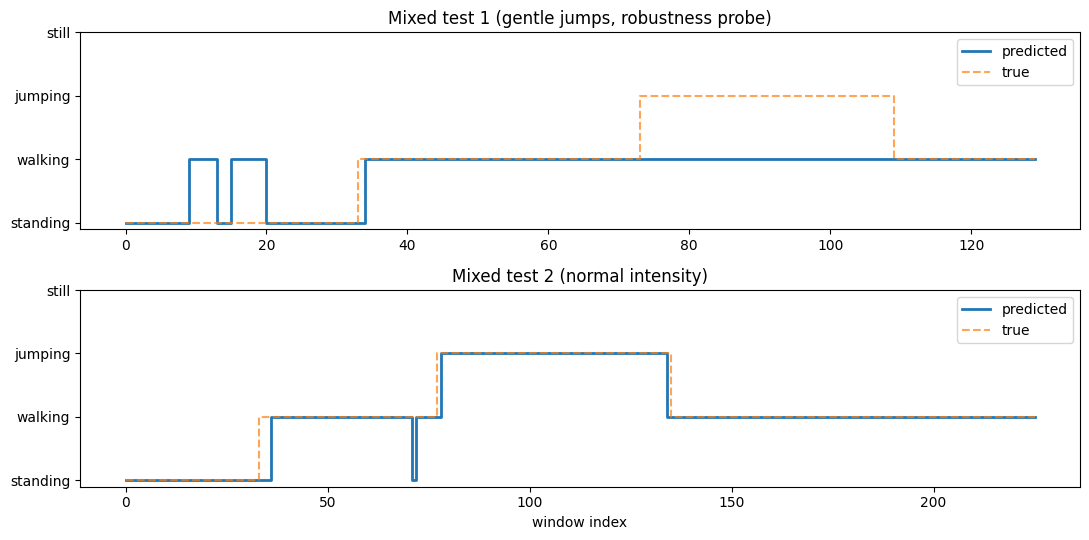

In [25]:
mixed_paths = ["mixed_test_01.csv", "mixed_test_02.csv"]
titles = ["Mixed test 1 (gentle jumps, robustness probe)",
          "Mixed test 2 (normal intensity)"]

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5))
for ax, mname, title in zip(axes, mixed_paths, titles):
    X, act, path = next(s for s in test_seqs if os.path.basename(s[2]) == mname)
    pred = np.array([state2act[s] for s in model.viterbi(X)])
    truth = pd.read_csv(path.replace(".csv", "_labels.csv"))["label"].values[:len(pred)]
    ax.step(range(len(pred)), [act2idx[p] for p in pred], where="post",
            label="predicted", lw=2)
    ax.step(range(len(truth)), [act2idx[t] for t in truth], where="post",
            label="true", ls="--", alpha=0.7)
    ax.set_yticks(range(len(ACTIVITIES)), ACTIVITIES)
    ax.set_title(title)
    ax.legend(loc="upper right")
axes[1].set_xlabel("window index")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/hmm_data/figure5_decoded_sequences.png",
            dpi=200, bbox_inches="tight")
plt.show()